Programme: PGDip Applied Data Analytics<br>
Course: SWRDC9011 Machine Learning and AI with Industrial Applications<br>
Lecturer: Dr A. Kaushik<br>
Student: D00285895 George Semain

# **Exploratory Data Analysis (EDA): A study of unstructured document data relating to an Irish Retail Bank**

### **Step 1: Identify Theme**

The ultimate aim of this study is to demonstrate Exploratory Data Analysis (EDA) in preparation for a Machine Learning application. Furthermore, the objective is to use this study to explore how EDA can be performed on an unstructured data source, such as document text.

In a prior assignment of this Machine Learning course (CA1) a use-case for Machine Learning was explored for the 'Context sensitive retrieval of information from documents'. Here, a machine leaning based solution would "enable a person to ask a question, and receive a natural language response based on the context of the question, where the answer to the question is expected to be derived from a specific knowledge-base database (corpus) compiled from an organisation's documentation".<br>
The theme of this study is a continuation of the first assignment.<br><br>
The approach is to identify a suitable example data source, and perform Exploratory Data Analysis in preparation for building the solution. The actual design and build of the solution is not intended to be included in this study, and would form subsequent work.<br><br>
This use-case is of potential value to all organisations across the world. If the ultimate application enables a user to select any number of documents from one or more source locations (can be a parameter to supply any number of discrete URLs) then this company-specific corpus can be available to a pre-trained language model for specific interrogation based on a user prompt, and response.

### **Step 2: Locate Suitable Source Data**

In order to perform the study, a number of example company-specific docuemnts needed to be sourced from the public domain. As the original idea for the study was in the context of a financial organisation, a search of available docuemnts for Irish Banks resulted in three types of example document being available for Permanent TSB - an Irish Retail Bank.

##### **Annual Reports**


1.   Annual Report 2024
2.   Annual Report 2023


##### **Pillar 3 Risk Disclosure Reports**


1.   Pillar 3 Disclosures Annual Report 2024
2.   Pillar 3 Disclosures Half-Year Report June 2025

##### **Sustainability Strategy & Disclosure Reports**


1.   Task Force on Climate-Related Financial Disclosures (TCFD) Report 2022
2.   Sustainability Strategy 2025-2027









This provides six company-specific documents available in the public domain in-keeping with the brief as the basis for this study.

### **Step 3: Import Data**

The six PDF documents were saved in a folder in Google Drive 'DKIT_ML_CA2'.<br>
The Google drive was connected to Google.Colab (once access permission was granted the confirmation message 'mounted at /content/drive' confirmed this was successful.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Validate that there is access to the MyDrive folder containing the six PDF source files.

In [ ]:
import os
mydrive_path = "/content/drive/MyDrive/DKIT_ML_CA2"
os.listdir(mydrive_path)

['ptsbgh-plc-pillar-3-report-2024.pdf',
 'ptsbgh-plc-pillar-3-half-year-report-2025.pdf',
 'ptsbgh-annual-report-2024.pdf',
 'ptsbgh-annual-report-2023.pdf',
 'dsc0623_tcfd_report_v15.pdf',
 'sustainability-strategy-2025-2027.pdf',
 'Copy of DKIT_ML_CA2_PTSB_Document_EDA (3).ipynb',
 'Copy of DKIT_ML_CA2_PTSB_Document_EDA (2).ipynb',
 'Copy of DKIT_ML_CA2_PTSB_Document_EDA (1).ipynb',
 'Copy of DKIT_ML_CA2_PTSB_Document_EDA.ipynb',
 'extracted_text.csv',
 'DKIT_ML_CA2_PTSB_Document_EDA.ipynb']

Create a list of the six PDF source filenames.

In [ ]:
doc_files = [
    f for f in os.listdir(mydrive_path)
    if f.lower().endswith(".pdf")
]

In [ ]:
doc_files

['ptsbgh-plc-pillar-3-report-2024.pdf',
 'ptsbgh-plc-pillar-3-half-year-report-2025.pdf',
 'ptsbgh-annual-report-2024.pdf',
 'ptsbgh-annual-report-2023.pdf',
 'dsc0623_tcfd_report_v15.pdf',
 'sustainability-strategy-2025-2027.pdf']

There is a variety of information releating to each document which is important to define and store. One of the benefits of the use-case is that when an automated response is given to a user (based on their question prompt) it will not only provide a natural language response, but also confirm the source document (and potentailly paragraph number/page number/section number) so that the user can inspect it manually if they choose to (perhaps to validate the response and obtain more information).<br><br>Information about data is called 'Meta data' and to store information on each document requires a suitable dataframe to be defined.

In [ ]:
import pandas as pd

metadata = pd.DataFrame({
    "file_name": doc_files
})

In [ ]:
metadata

,file_name
0,ptsbgh-plc-pillar-3-report-2024.pdf
1,ptsbgh-plc-pillar-3-half-year-report-2025.pdf
2,ptsbgh-annual-report-2024.pdf
3,ptsbgh-annual-report-2023.pdf
4,dsc0623_tcfd_report_v15.pdf
5,sustainability-strategy-2025-2027.pdf


Define additional metadata attributes to give each document a unique identification code (automatically incrementing each time), and to store the company name and document title. Additional metrics will be added later as part of EDA.

In [ ]:
metadata["doc_id"] = [f"doc_{i+1:02d}" for i in range(len(metadata))]
metadata["org_name"] = "Permanent TSB"

In [ ]:
metadata

,file_name,doc_id,org_name
0,ptsbgh-plc-pillar-3-report-2024.pdf,doc_01,Permanent TSB
1,ptsbgh-plc-pillar-3-half-year-report-2025.pdf,doc_02,Permanent TSB
2,ptsbgh-annual-report-2024.pdf,doc_03,Permanent TSB
3,ptsbgh-annual-report-2023.pdf,doc_04,Permanent TSB
4,dsc0623_tcfd_report_v15.pdf,doc_05,Permanent TSB
5,sustainability-strategy-2025-2027.pdf,doc_06,Permanent TSB


Importing the document data requires extracting the text from each document. As teh documents are in Portable Definition Format (PDF) I need to use a suitable utility to read PDFs. One utility is 'pdfplumber'.

In [ ]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 93.3 MB/s eta 0:00:00


Test reading the text from the first PDF file.

In [ ]:
import pdfplumber
import numpy as np

test_file = doc_files[0] # first file listed in the folder
test_path = f"{mydrive_path}/{test_file}"

with pdfplumber.open(test_path) as pdf:
    print("Number of pages:", len(pdf.pages))
    first_page_text = pdf.pages[0].extract_text()
    print(test_file, first_page_text)

Number of pages: 193
ptsbgh-plc-pillar-3-report-2024.pdf Confidential!


By inspection, the first four pages of the document are as follows:
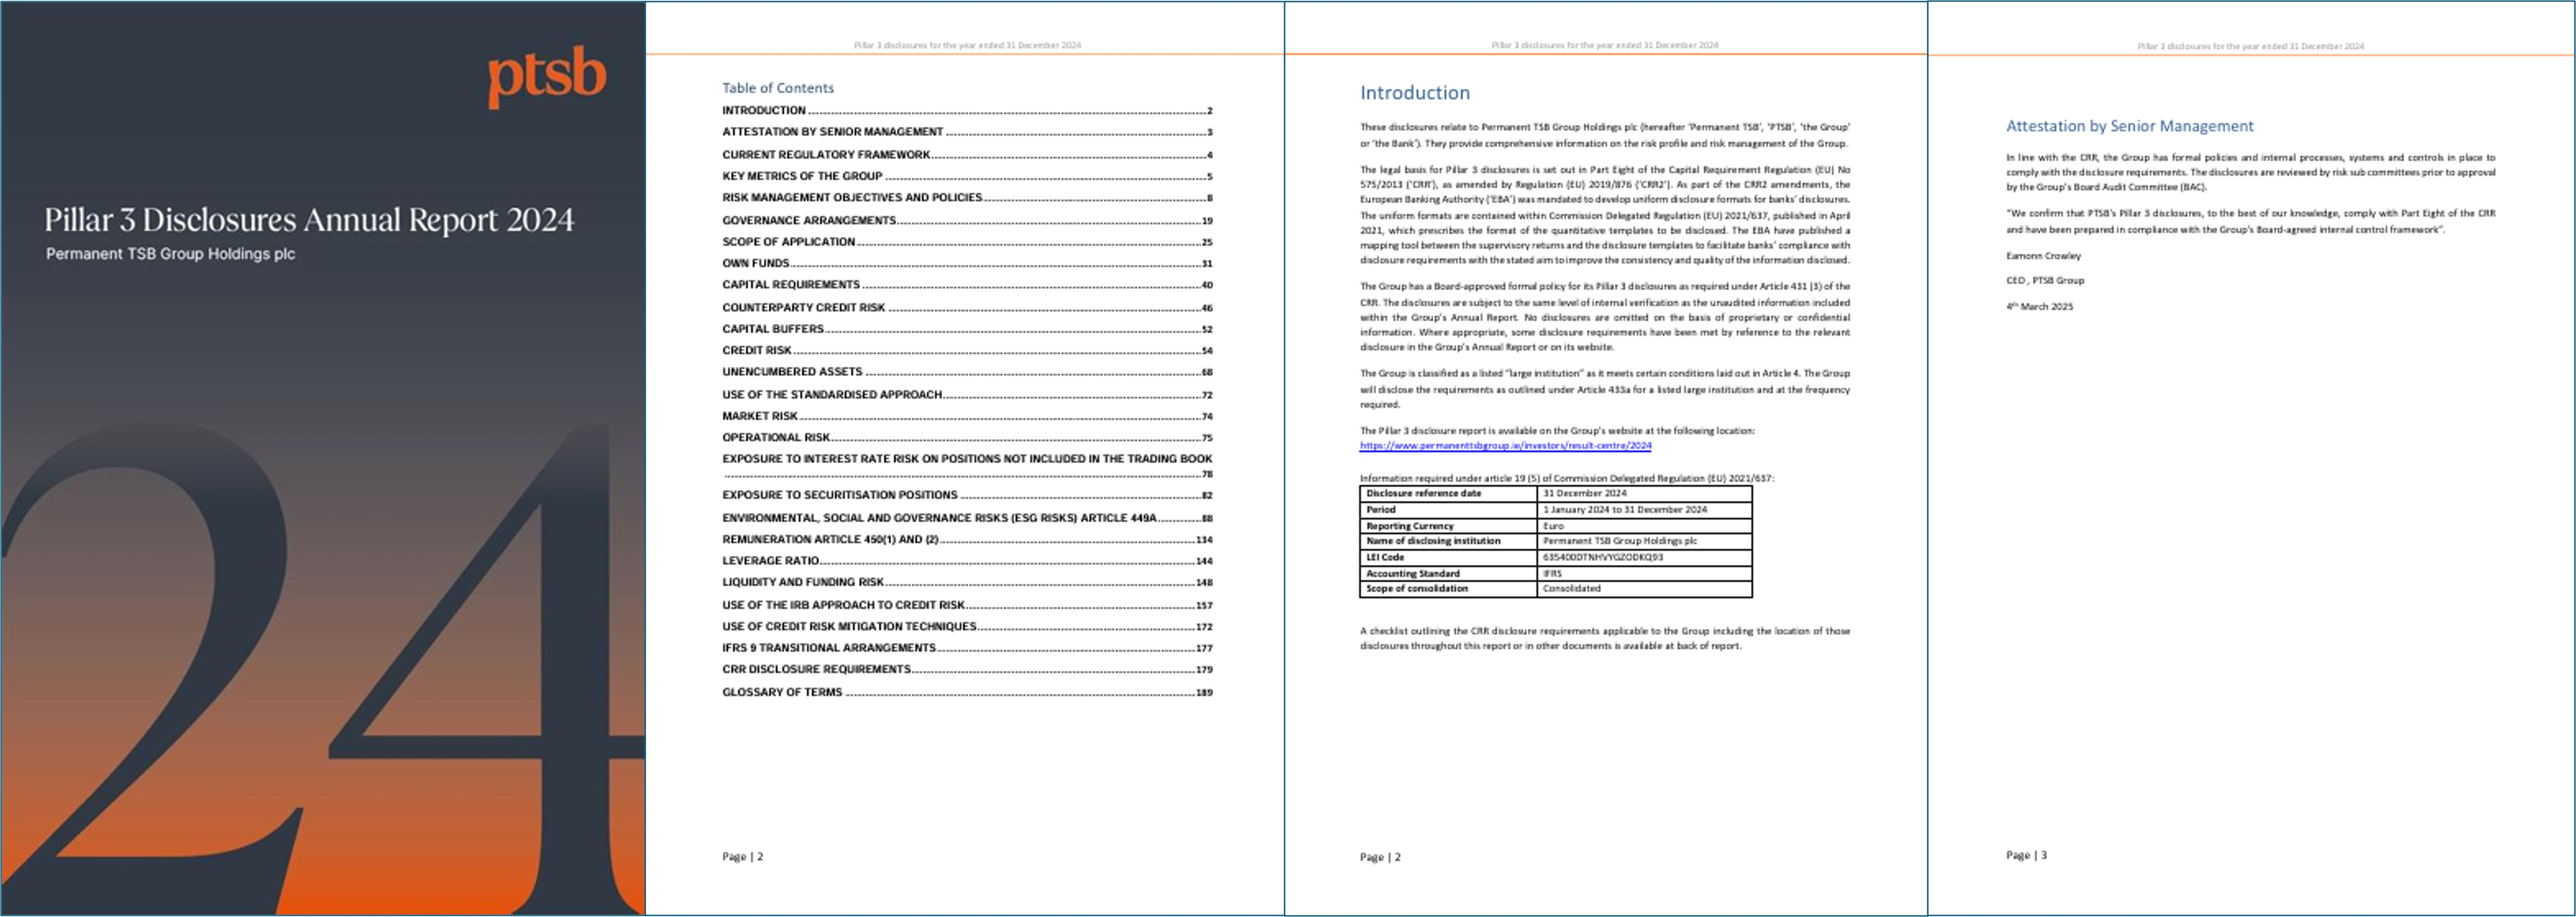


The first page is an image, and is not a good test to determine teh ability to extract text. Page 4 is a simple page of text (no tables or images) and hence that will be a good test.

In [ ]:
with pdfplumber.open(test_path) as pdf:
    print("Test file:", test_file)
    print("Number of pages:", len(pdf.pages))
    fourth_page_text = pdf.pages[3].extract_text()
    print(fourth_page_text)

Test file: ptsbgh-plc-pillar-3-report-2024.pdf
Number of pages: 193
Pillar 3 disclosures for the year ended 31 December 2024
Attestation by Senior Management
In line with the CRR, the Group has formal policies and internal processes, systems and controls in place to
comply with the disclosure requirements. The disclosures are reviewed by risk sub committees prior to approval
by the Group’s Board Audit Committee (BAC).
“We confirm that PTSB's Pillar 3 disclosures, to the best of our knowledge, comply with Part Eight of the CRR
and have been prepared in compliance with the Group's Board-agreed internal control framework”.
Eamonn Crowley
CEO , PTSB Group
4th March 2025
Page | 3


By inspection, this is an accurate (perfect) extraction of the text on page 4.

As a further test, it is interesting to see how the reader can handletext in tables such as page 3, which also includes a link to a URL.

In [ ]:
with pdfplumber.open(test_path) as pdf:
    print("Test file:", test_file)
    print("Number of pages:", len(pdf.pages))
    third_page_text = pdf.pages[2].extract_text()
    print(third_page_text)

Test file: ptsbgh-plc-pillar-3-report-2024.pdf
Number of pages: 193
Pillar 3 disclosures for the year ended 31 December 2024
Introduction
These disclosures relate to Permanent TSB Group Holdings plc (hereafter ‘Permanent TSB’, ‘PTSB’, ‘the Group’
or ‘the Bank’). They provide comprehensive information on the risk profile and risk management of the Group.
The legal basis for Pillar 3 disclosures is set out in Part Eight of the Capital Requirement Regulation (EU) No
575/2013 (‘CRR’), as amended by Regulation (EU) 2019/876 (‘CRR2’). As part of the CRR2 amendments, the
European Banking Authority (‘EBA’) was mandated to develop uniform disclosure formats for banks’ disclosures.
The uniform formats are contained within Commission Delegated Regulation (EU) 2021/637, published in April
2021, which prescribes the format of the quantitative templates to be disclosed. The EBA have published a
mapping tool between the supervisory returns and the disclosure templates to facilitate banks’ compliance 

Observations:

*   The page header text was extracted - although there is no way of knowing it is header text as opposed to normal page text.
*   It is possible to see a paragraph end, differentiated from a sentence end. Ther may be a 'carriage return' character that isn't clearly readable.
*   The URL link seems to be displayed as a link - this may just be the Google Colab Notebook converting this.
*   The data within the table cells (two columns) has successfuly been extracted, albeit without any formatting.
*   The page footer text (page number) has been extracted.
*   The text has been extracted accurately.

Having proven the ability to extract document text, the next stage is to iterate through each document, and determine basic document metrics:

*   number of pages (with text)
*   number of empty pages (no text)
*   word count
*   document text that has been extracted

The following function can be used to gather basic metrics on each document.

In [ ]:
def extract_document_metrics(pdf_path):
    text_pages = [] # used to store the text on each page
    empty_pages = 0 # used to count teh number of empty pages

    with pdfplumber.open(pdf_path) as pdf:
        # process each page
        for page in pdf.pages:
            # extract teh text on teh page
            page_text = page.extract_text()
            # determine if its a blank page and if so increment teh empty page counter and set teh page text to be empty
            if page_text is None or page_text.strip() == "":
                empty_pages += 1
                text_pages.append("")
            # if not blank, add teh page text as a new string in text_pages
            else:
                text_pages.append(page_text)
    # concatenate all of teh text pages strings witha new line separating them
    full_text = "\n".join(text_pages)
    #use teh .split() method to separate teh full text into words (separating on spaces, tabs, new lines, ...)
    # and count the number of items (words) in teh list)
    word_count = len(full_text.split())

    return {
        "n_pages": len(text_pages),
        "empty_pages": empty_pages,
        "word_count": word_count,
        "text": full_text
    }

The following routine iterates through each filename and calls the 'extract_document_metrics()' function

In [ ]:
extracted_results = []
#iterate through each file
for file_name in doc_files:
    file_path = f"{mydrive_path}/{file_name}"
    # in each case call teh function and return the data into metrics
    try:
        metrics = extract_document_metrics(file_path)
        # add teh filename
        metrics["file_name"] = file_name
        # add a boolean flag confirming teh document extraction routine completed successfuly
        metrics["extraction_success"] = True
    # if teh routine fails, store empty values for each metric with a boolean flag confirming extraction was not successful
    except Exception as e:
        metrics = {
            "file_name": file_name,
            "n_pages": np.nan,
            "empty_pages": np.nan,
            "word_count": np.nan,
            "text": "",
            "extraction_success": False
        }
    # append teh metrics to extracted_results
    extracted_results.append(metrics)

This took a few minutes to run as it is processing a lot of data.<br><br>
The next step is to take store teh appended metrics in a dataframe,

In [ ]:
extracted_df = pd.DataFrame(extracted_results)

metadata = metadata.merge(
    # remove the column containing the detailed text
    extracted_df.drop(columns=["text"]),
    # merge where there is a match on file_name
    on="file_name",
    # keep existing metadat columsn for each filename
    how="left"
)

# show teh dataframe
metadata

,file_name,doc_id,org_name,n_pages,empty_pages,word_count,extraction_success
0,ptsbgh-plc-pillar-3-report-2024.pdf,doc_01,Permanent TSB,193,0,107421,True
1,ptsbgh-plc-pillar-3-half-year-report-2025.pdf,doc_02,Permanent TSB,117,0,62146,True
2,ptsbgh-annual-report-2024.pdf,doc_03,Permanent TSB,424,1,260032,True
3,ptsbgh-annual-report-2023.pdf,doc_04,Permanent TSB,340,0,205585,True
4,dsc0623_tcfd_report_v15.pdf,doc_05,Permanent TSB,49,0,13878,True
5,sustainability-strategy-2025-2027.pdf,doc_06,Permanent TSB,22,0,3643,True


All six documents processes successfuly.

In [ ]:
pages_processed = metadata["n_pages"].sum()
total_words = metadata["word_count"].sum()
print(f"Pages processed: {pages_processed:,}")
print(f"Total words: {total_words:,}")


Pages processed: 1,145
Total words: 652,705


The extracted text was not saved to the metadata dataframe, instead will be saved to a csv file so that it can be read easily for future processing without having to extract the pdf files again. Each record will contain just teh filename and the full extracted text string.

In [ ]:
text_store = extracted_df[["file_name", "text"]]
text_store.to_csv("/content/drive/MyDrive/DKIT_ML_CA2/extracted_text.csv", index=False)

Checking Google Drive shows the csv file was saved.<br>
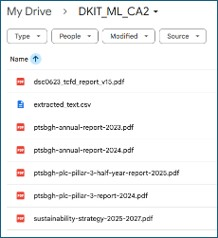

It is helpful to store the percentage of empty pages per document as a quality metric (albeit the number of empty pages is very low).

In [ ]:
metadata["percent_empty_pages"] = (
    metadata["empty_pages"] / metadata["n_pages"]
) * 100

In [ ]:
metadata

,file_name,doc_id,org_name,n_pages,empty_pages,word_count,extraction_success,percent_empty_pages
0,ptsbgh-plc-pillar-3-report-2024.pdf,doc_01,Permanent TSB,193,0,107421,True,0.000000
1,ptsbgh-plc-pillar-3-half-year-report-2025.pdf,doc_02,Permanent TSB,117,0,62146,True,0.000000
2,ptsbgh-annual-report-2024.pdf,doc_03,Permanent TSB,424,1,260032,True,0.235849
3,ptsbgh-annual-report-2023.pdf,doc_04,Permanent TSB,340,0,205585,True,0.000000
4,dsc0623_tcfd_report_v15.pdf,doc_05,Permanent TSB,49,0,13878,True,0.000000
5,sustainability-strategy-2025-2027.pdf,doc_06,Permanent TSB,22,0,3643,True,0.000000


In [ ]:
percent_empty_pages = (metadata["percent_empty_pages"].sum() / metadata["n_pages"].sum()) * 100
print(f"Percentage of pages that are empty: {percent_empty_pages:,.2f}%")


Percentage of pages that are empty: 0.02%


Observations:

*   The annual reports are the largest files
*   The Sustainability documents are relatively much smaller
*   The method to extract text from PDF documents appears to be suitable to perform further EDA
*   The quality of the text extract appears to be very good - 0.02% empty pages can be considered negligible.
*   The differences in document metrics demonstrates heterogeneity



### **Step 4: Enrich Metadata**

Other information on each document that can be stored as metadat includes teh following categorical attributes

*   the type of document
*   the reporting year (albeit this is only valid for reports)
*   the reporting period (albeit this is only valid for reports)
*   the publication date (albeit this may need to be inferred if not explicitly known)

The publication date can be particularly interesting if we only wanted to show results for most recent versions of documents. Even though it may not be known exactly, an indicative publication date is sufficient.<br><br>
These four attributes cannot be inferred programmatically, and hence are labelled manually below.


In [ ]:
from datetime import datetime

metadata["doc_type"] = ["Pillar 3","Pillar 3", "Annual Report","Annual Report", "Sustainability", "Sustainability"]
metadata["reporting_year"] = [2024, 2025, 2024, 2023, 2022, 2025]
metadata["reporting_period"] = ["Full Year","Half Year", "Full Year","Full Year", "Full Year", "Multi Year"]
date1=datetime(2025, 3, 31)
date2=datetime(2025, 11, 30)
date3=datetime(2025, 3, 31)
date4=datetime(2024, 3, 31)
date5=datetime(2023, 3, 31)
date6=datetime(2024, 12, 31)

metadata["issue_date"] = [date1,date2,date3,date4,date5,date6]

print(metadata.dtypes)

file_name                      object
doc_id                         object
org_name                       object
n_pages                         int64
empty_pages                     int64
word_count                      int64
extraction_success               bool
percent_empty_pages           float64
doc_type                       object
reporting_year                  int64
reporting_period               object
issue_date             datetime64[ns]
dtype: object


In [ ]:
metadata

,file_name,doc_id,org_name,n_pages,empty_pages,word_count,extraction_success,percent_empty_pages,doc_type,reporting_year,reporting_period,issue_date
0,ptsbgh-plc-pillar-3-report-2024.pdf,doc_01,Permanent TSB,193,0,107421,True,0.000000,Pillar 3,2024,Full Year,2025-03-31
1,ptsbgh-plc-pillar-3-half-year-report-2025.pdf,doc_02,Permanent TSB,117,0,62146,True,0.000000,Pillar 3,2025,Half Year,2025-11-30
2,ptsbgh-annual-report-2024.pdf,doc_03,Permanent TSB,424,1,260032,True,0.235849,Annual Report,2024,Full Year,2025-03-31
3,ptsbgh-annual-report-2023.pdf,doc_04,Permanent TSB,340,0,205585,True,0.000000,Annual Report,2023,Full Year,2024-03-31
4,dsc0623_tcfd_report_v15.pdf,doc_05,Permanent TSB,49,0,13878,True,0.000000,Sustainability,2022,Full Year,2023-03-31
5,sustainability-strategy-2025-2027.pdf,doc_06,Permanent TSB,22,0,3643,True,0.000000,Sustainability,2025,Multi Year,2024-12-31


### **Step 5 Descriptive Statistics**
The quantitative attributes of the metadata enable analysis of central tendency, variability & spread and range of values.

In [ ]:
metadata[["n_pages", "word_count", "percent_empty_pages"]].describe()

,n_pages,word_count,percent_empty_pages
count,6.000000,6.000000,6.000000
mean,190.833333,108784.166667,0.039308
std,161.675498,104388.821849,0.096285
min,22.000000,3643.000000,0.000000
25%,66.000000,25945.000000,0.000000
50%,155.000000,84783.500000,0.000000
75%,303.250000,181044.000000,0.000000
max,424.000000,260032.000000,0.235849


In [ ]:
metadata.groupby("doc_type")[["n_pages", "word_count"]].agg(["mean", "min", "max"])

n_pages           word_count                
                  mean  min  max       mean     min     max
doc_type                                                   
Annual Report    382.0  340  424   232808.5  205585  260032
Pillar 3         155.0  117  193    84783.5   62146  107421
Sustainability    35.5   22   49     8760.5    3643   13878

The document sizes per type are clearly of a different order of magnitude, with Pillar 3 having 10x the number of words as Sustainability document types, and Annual Reports being 3x the size of Pillar 3 reports.

### **Step 6 Visualisations**
##### *<u>Distribution of Document Length (Pages)*</u>

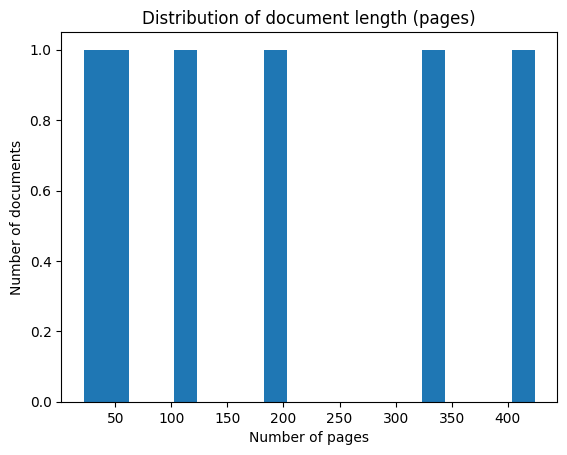

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(metadata["n_pages"], bins=20)
plt.xlabel("Number of pages")
plt.ylabel("Number of documents")
plt.title("Distribution of document length (pages)")
plt.show()

As noted previously, this reinforces the variability in size of documents. There are only six documents - if this were a full analysis of all documents for an organisation there could be >100 documents being processed.


##### *<u>Distribution of Document Length (Words)*</u>

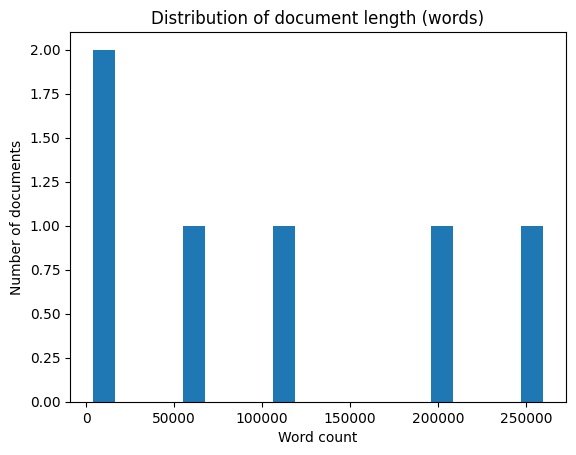

In [ ]:
plt.figure()
plt.hist(metadata["word_count"], bins=20)
plt.xlabel("Word count")
plt.ylabel("Number of documents")
plt.title("Distribution of document length (words)")
plt.show()

The distribution of words appears to be consistent with the distribution of pages.<br><br>
There are more documents to the left of the distribution (right-skewed). It is the annual reports that are the high values in both distributions.

##### *<u>Document Length (Pages) by document type*</u>

<Figure size 640x480 with 0 Axes>

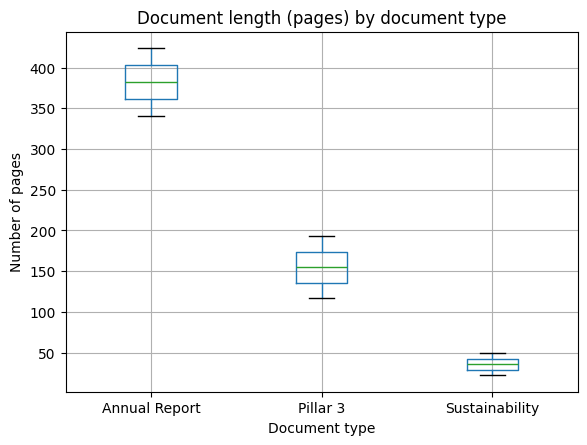

In [ ]:
plt.figure()
metadata.boxplot(column="n_pages", by="doc_type")
plt.xlabel("Document type")
plt.ylabel("Number of pages")
plt.title("Document length (pages) by document type")
plt.suptitle("")
plt.show()

##### *<u>Document Length (Words) by document type*</u>

<Figure size 640x480 with 0 Axes>

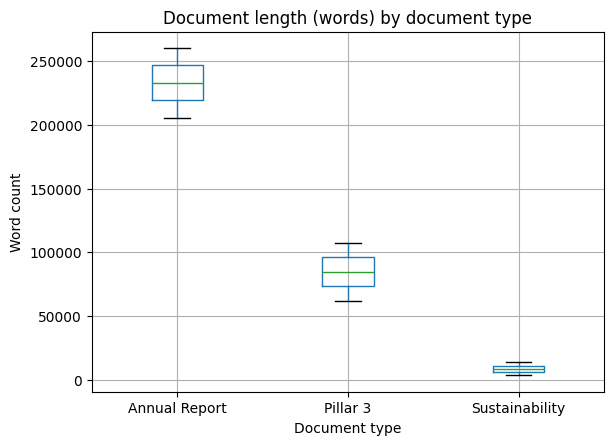

In [ ]:
plt.figure()
metadata.boxplot(column="word_count", by="doc_type")
plt.xlabel("Document type")
plt.ylabel("Word count")
plt.title("Document length (words) by document type")
plt.suptitle("")
plt.show()

The Annual Reports clearly contain significantly more text than other document types. This may be a consideration for how Annual Report documents are treated in subsequent machine learning.<br><br>We can see that the box-plots for number of pages and word count for each document type are almost mirror images. A notable difference is that the range for Sustainability documents is much smaller for 'words' than it is for 'pages'. What can be inferred by this is that the pages for Sustainability have less concentration of words per page than Annual Reports and Pillar 3 documents.<br><br>
As stated previously, the box plot reinforces that there is heterogeneity across document types.

##### *<u>Proportion of empty pages per document*</u>


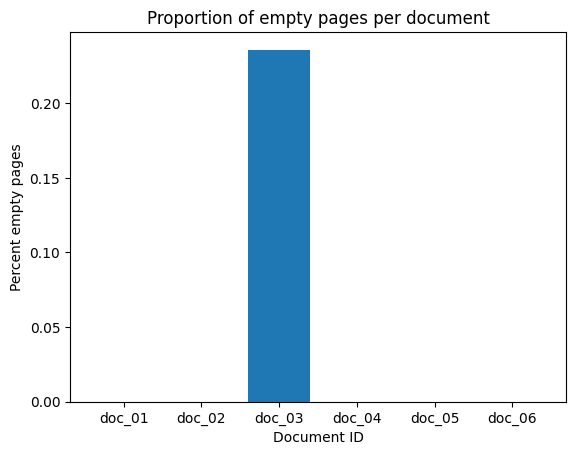

In [ ]:
plt.figure()
plt.bar(metadata["doc_id"], metadata["percent_empty_pages"])
plt.xlabel("Document ID")
plt.ylabel("Percent empty pages")
plt.title("Proportion of empty pages per document")
plt.show()

The proportion of empty pages extracted is negligible - this is indicative of the documents being composed primarily of text (as opposed to full pages of pictures being used in isolation or to represent text - which could not be extracted by the PDF reader).

### **Step 7 Words & Vocabulary Analysis**
In order to perform some further analysis of the 'language' of each document/document type it is necessary, first, to merge the document text with the metadata.

In [ ]:
text_df = pd.read_csv("/content/drive/MyDrive/DKIT_ML_CA2/extracted_text.csv")

text_df.head()

,file_name,text
0,ptsbgh-plc-pillar-3-report-2024.pdf,Confidential!\nPillar 3 disclosures for the ye...
1,ptsbgh-plc-pillar-3-half-year-report-2025.pdf,Confidential!\nPillar 3 disclosures for 30 Jun...
2,ptsbgh-annual-report-2024.pdf,Annual Report 2024\nPermanent TSB Group Holdin...
3,ptsbgh-annual-report-2023.pdf,Annual Report 2023\nPermanent TSB Group Holdin...
4,dsc0623_tcfd_report_v15.pdf,TASK FORCE ON\nCLIMATE-RELATED\nFINANCIAL DISC...


In [ ]:
# merge text with metadata (on filename)
doc_text = metadata.merge(text_df, on="file_name", how="left")

It is necessary to do some simple pre-processing prior to language analysis, to ensure accurate results and simplify the text being processed.

In [ ]:
# import teh regular expressions library which enables some text cleaning
import re

# define teh function to clean teh text for analysis
def simple_preprocess(text):
    # convert all text to lower case - this ensures a word spelled teh same as any otehr word is treated as the same word
    text = text.lower()
    # replace any character that is not a lowercase letter or a space with a space (removes punctuation)
    text = re.sub(r"[^a-z\s]", " ", text)

    # replace any whitespace character, or string of white space characters, with a single space
    text = re.sub(r"\s+", " ", text)
    # remove any spaces at the start or end of teh text
    return text.strip()

#create a new column 'clean_text' in teh dataframe having run teh function
doc_text["clean_text"] = doc_text["text"].apply(simple_preprocess)


Note the basic pre-processing does not perform any lemmatisation of words to their root form.

##### *<u>Word frequency count</u>*

In [ ]:
# import teh Counter data type so that its easy to count each word
from collections import Counter

# join teh six cleaned text strings with a space separator, and split it into a list of separate words
all_words = " ".join(doc_text["clean_text"]).split()

# count each word using a counter object
word_counts = Counter(all_words)

#create a dataframe of the 20 most common words across all six documents, noting teh word and the count
common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "count"]
)

# display teh 20 most common words and the number of times each appeared in the six docs
common_words

,word,count
0,the,29511
1,and,18940
2,of,16752
3,to,13264
4,a,10205
5,in,9489
6,s,6714
7,e,6107
8,risk,5657
9,for,4855


Observations:

*   There's a lot of common 'small' words like the, a, in, is, for, ... these are not very interesting
*   There's a lot of single letters
<br>The single letters can be attributed to the type of documents being processed. Regulatory banking text can have a lot of repeated acronyms (e.g. SEPA, AML, SSM, EBA, CRR, ...) which can be interpreted by the PDF reader as individual characters, or related to the way the text was formatted in the source document.<br><br>
For meaningful insights as part of exploratory analysis, it is necessary to perform additional cleaning/pre-processing of the text.


*   Remove small words (known as 'stopwords')
*   Remove spurious letters



In [ ]:
# scikitlearn has various tools for feature extraction from text (and converting to numerical data)ENGLISH_STOP_WORDS
# ENGLISH_STOP_WORDS is teh set of pre-defined small words
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords = set(ENGLISH_STOP_WORDS)

# keep only words that are not in stopwprds and are >=3 characters
filtered_words = [
    w for w in all_words
    if w not in stopwords and len(w) >= 3
]

# count the new list of words
filtered_word_counts = Counter(filtered_words)

# create a new data frame for teh 20 most common words, after this additional processing
filtered_common_words = pd.DataFrame(
    filtered_word_counts.most_common(20),
    columns=["word", "count"]
)
# display the 20 most common words
filtered_common_words

,word,count
0,risk,5657
1,bank,3875
2,group,3361
3,board,2446
4,financial,2146
5,management,1997
6,ptsb,1782
7,committee,1683
8,business,1534
9,december,1326


This is much more insightful and meaningful than before.

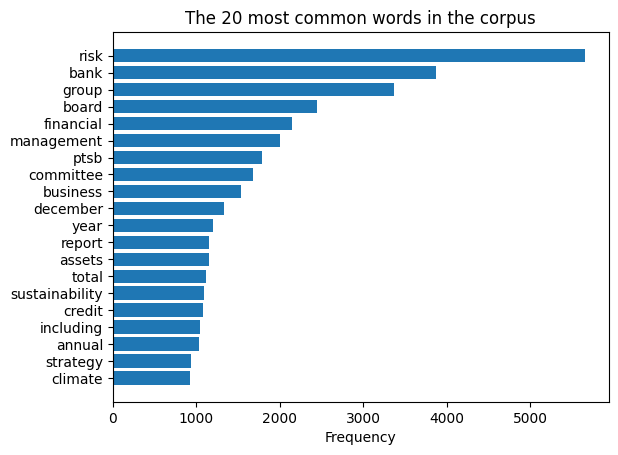

In [ ]:
plt.figure()
plt.barh(
    filtered_common_words["word"],
    filtered_common_words["count"]
)
plt.xlabel("Frequency")
plt.title("The 20 most common words in the corpus")
plt.gca().invert_yaxis()
plt.show()

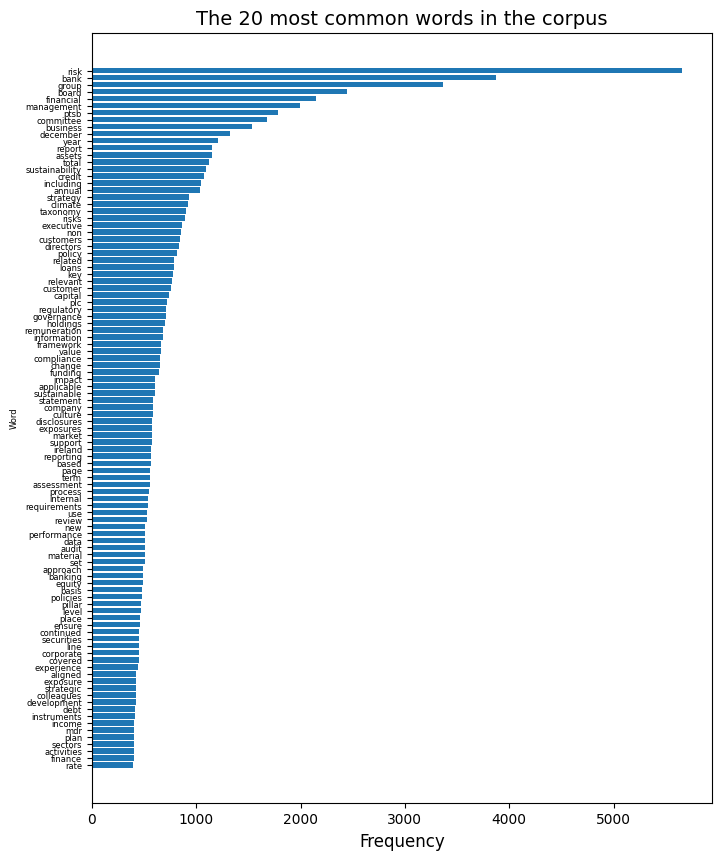

In [ ]:
# repeat for the 100 most common words
filtered_common_words = pd.DataFrame(
    filtered_word_counts.most_common(100),
    columns=["word", "count"]
)

# Adjust teh size of teh plot
plt.figure(figsize=(8, 10))

plt.barh(
    filtered_common_words["word"],
    filtered_common_words["count"]
)

# Labels and title
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Word", fontsize=6)
plt.title("The 20 most common words in the corpus", fontsize=14)
plt.yticks(fontsize=6)

plt.gca().invert_yaxis()
plt.show()

The frequency of banking, regulatory, financial and risk-related words is totally expected based on the nature of these documents

##### *<u>Word usage by document type</u>*

In [ ]:
from collections import Counter

# word count as before but categorise by doctype
def top_words_by_doc_type(df, text_col, group_col, n=10):
    results = []
    for doc_type, subset in df.groupby(group_col):
        words = " ".join(subset[text_col]).split()
        words = [w for w in words if w not in stopwords and len(w) >= 3]
        counter = Counter(words).most_common(n)

        for word, count in counter:
            results.append({
                "doc_type": doc_type,
                "word": word,
                "count": count
            })
    return pd.DataFrame(results)

# extract teh top 10 words for each document type
top_words_dt = top_words_by_doc_type(
    doc_text,
    text_col="clean_text",
    group_col="doc_type",
    n=10
)

top_words_dt

,doc_type,word,count
0,Annual Report,risk,3380
1,Annual Report,group,2855
2,Annual Report,bank,2741
3,Annual Report,board,2124
4,Annual Report,financial,1808
5,Annual Report,management,1513
6,Annual Report,ptsb,1489
7,Annual Report,committee,1482
8,Annual Report,business,1118
9,Annual Report,december,1039


Annual report and pillar 3 document types have a similar top 10 vocabulary, and Sustainability has different words pertaining to Environmental, Social, Governance (ESG)-related activities.

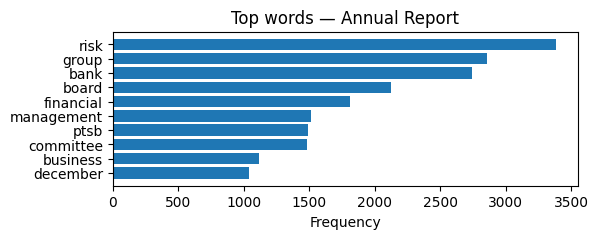

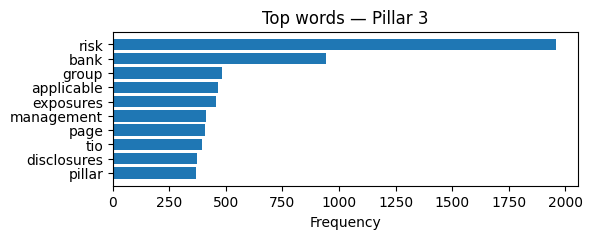

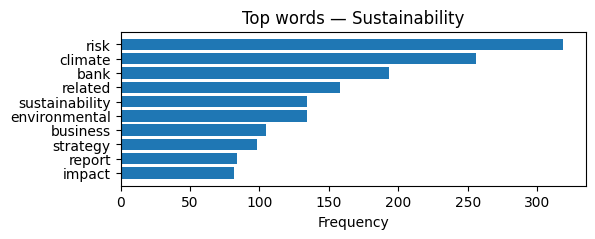

In [ ]:
for dt in top_words_dt["doc_type"].unique():
    subset = top_words_dt[top_words_dt["doc_type"] == dt]

    # Adjust teh size of teh plot
    plt.figure(figsize=(6, 2))
    #plt.figure()
    plt.barh(subset["word"], subset["count"])
    plt.title(f"Top words — {dt}")
    plt.xlabel("Frequency")
    plt.gca().invert_yaxis()
    plt.show()

There are a few observations that could form part of further processing. <br><br>The word 'page' in Pillar 3 document types could be frequent if it is in the footer of every page (for a page number) and where there are references to different pages within the document. The word could be dropped from the analysis.<br><br>It is unclear what the word 'tio' represents, and it might be pertinent to drop it.

##### *<u>Term Frequency x Inverse Document Frequency</u>*

In this analysis the aim is to determine what makes each document different from other documents.<br>
Term Frequency (TF) has already been assessed by counting the frequency of words per document.<br><br>
Inverse Document Frequency (IDF) looks across all documents in the corpus and determines if it is common across all docuemnts, or specific to this one document. It is a way of differentiating specific words by document. A low IDF means it is common across other documents, wheras a high IDF value means it is distinctive to this document.<br><br>
Hence, a high TF-IDF score implies it appears frequently in this document but not in others.<br><br>
It will enable comparison of whether documents differ in their meaning and use of language. In effect it assesses whether or not documents 'cluster' based similar common words.<br><br>
Note this is an intermediate representation used in subsequent exploration.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    # limit the number of words to 500 to reduce noise and avoid overfitting (keep it meaningful)
    max_features=500
)

tfidf_matrix = vectorizer.fit_transform(doc_text["clean_text"])

##### *<u>Document Similarity (cosine similarity)</u>*
As opposed to comparing docuemnts in terms of teh words contained therein, the cosine similarity considers the documents as a whole. <br><br>
Having created a vector for each document from TF-IDF above, the similarity of vectors (angle) can be compared and represented with a value between 1 and 0, where 1 indicates very similar language and 0 represents very different language.<br><br>
Scikitlearn has a pecific module for cosine similarity.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# pass teh tf-idf matrix (per document) produced earlier, to teh cosine similarity function
similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=doc_text["doc_id"],
    columns=doc_text["doc_id"]
)

similarity_df

doc_id,doc_01,doc_02,doc_03,doc_04,doc_05,doc_06
doc_id,,,,,,
doc_01,1.000000,0.932674,0.627040,0.643491,0.574987,0.350900
doc_02,0.932674,1.000000,0.547121,0.561816,0.555062,0.412703
doc_03,0.627040,0.547121,1.000000,0.886241,0.598981,0.516523
doc_04,0.643491,0.561816,0.886241,1.000000,0.663531,0.535467
doc_05,0.574987,0.555062,0.598981,0.663531,1.000000,0.580191
doc_06,0.350900,0.412703,0.516523,0.535467,0.580191,1.000000


In [ ]:
metadata

,file_name,doc_id,org_name,n_pages,empty_pages,word_count,extraction_success,percent_empty_pages,doc_type,reporting_year,reporting_period,issue_date
0,ptsbgh-plc-pillar-3-report-2024.pdf,doc_01,Permanent TSB,193,0,107421,True,0.000000,Pillar 3,2024,Full Year,2025-03-31
1,ptsbgh-plc-pillar-3-half-year-report-2025.pdf,doc_02,Permanent TSB,117,0,62146,True,0.000000,Pillar 3,2025,Half Year,2025-11-30
2,ptsbgh-annual-report-2024.pdf,doc_03,Permanent TSB,424,1,260032,True,0.235849,Annual Report,2024,Full Year,2025-03-31
3,ptsbgh-annual-report-2023.pdf,doc_04,Permanent TSB,340,0,205585,True,0.000000,Annual Report,2023,Full Year,2024-03-31
4,dsc0623_tcfd_report_v15.pdf,doc_05,Permanent TSB,49,0,13878,True,0.000000,Sustainability,2022,Full Year,2023-03-31
5,sustainability-strategy-2025-2027.pdf,doc_06,Permanent TSB,22,0,3643,True,0.000000,Sustainability,2025,Multi Year,2024-12-31


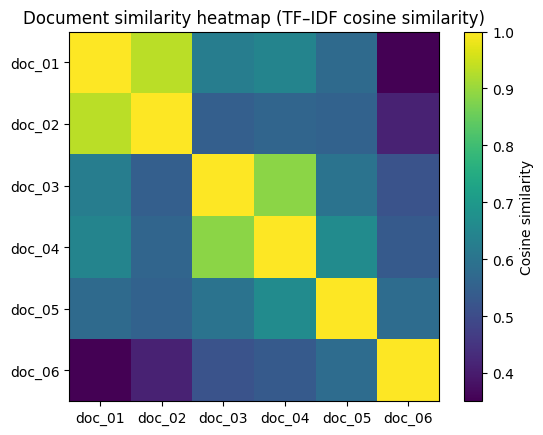

In [ ]:
# heatmap of TF-IDF similarity between documents

plt.figure()
plt.imshow(similarity_matrix)
plt.colorbar(label="Cosine similarity")
plt.xticks(range(len(doc_text)), doc_text["doc_id"])
plt.yticks(range(len(doc_text)), doc_text["doc_id"])
plt.title("Document similarity heatmap (TF–IDF cosine similarity)")
plt.show()

Observations:

*   Clearly there is similarity in the text used in the annual reports and the pillar 3 reports.
*   The text used in Sustainability documents is quite different form that used in Annual reports and Pillar 3 reports.



##### *<u>Unsupervised Document Clustering (K-means clustering)</u>*
This technique looks at each document and compares it to other documents for similarity, but does not use categorical metadata (labels such as doc_type) to assist the process. Once clusters are identified, they can be compared with the known (labelled) document types. This provides further evidence of similarity and difference between documents and document types.<br><br>
The k-means cluster technique is provided as a module within the scikitlearn library. It enables a k-means cluster model to be created based on the data provided.

In [ ]:
from sklearn.cluster import KMeans

# n is set to 3 - trying to fit into 3 clusters (we know we have 3 document types)
kmeans = KMeans(n_clusters=3, random_state=42)
# each docuemnt is assigne dto a cluster based on teh tfidf vector previously generated
doc_text["cluster"] = kmeans.fit_predict(tfidf_matrix)

doc_text[["doc_id", "doc_type", "cluster"]]

,doc_id,doc_type,cluster
0,doc_01,Pillar 3,2
1,doc_02,Pillar 3,2
2,doc_03,Annual Report,0
3,doc_04,Annual Report,0
4,doc_05,Sustainability,0
5,doc_06,Sustainability,1


This is very interesting, as it grouped pillar 3 documents as one cluster, annual reports as a notehr cluster, but for sustainability, it included the sustainability regulatory report with the same cluster as annual report documents. The Sustainability Strategy was clustered separately.<br><br>
This can be explained, as doc_05 is a regulatory report which provides a risk and financial assessment of the bank's sustainability performance. The language will be formal and similar to that of an annual report. Indeed the annual report will include a summary of the sustainability report. The doc_06 sustainability document is a strategy. It uses different types of language to describe the vision and intent of teh bank on its sustainability journey. The language and tone of such a strategy document can be expected to differ to that of a regulatory report.<br><br> Out of interest, it will be interesting to repeat the k-means cluster for n=2. It is expected that it will cluster doc_01 to doc_05 together, with doc_06 Sustainability Strategy separate.

In [ ]:
# n is set to 2
kmeans = KMeans(n_clusters=2, random_state=42)

doc_text["cluster"] = kmeans.fit_predict(tfidf_matrix)

doc_text[["doc_id", "doc_type", "cluster"]]

,doc_id,doc_type,cluster
0,doc_01,Pillar 3,0
1,doc_02,Pillar 3,0
2,doc_03,Annual Report,0
3,doc_04,Annual Report,0
4,doc_05,Sustainability,0
5,doc_06,Sustainability,1


As expected, this is the observed document clustering for n=2.

In [ ]:
# list the top terms for each cluster

feature_names = vectorizer.get_feature_names_out()

for cluster_id in sorted(doc_text["cluster"].unique()):
    # it is necessary to use a mask as a numpy array to avoid an error
    mask = (doc_text["cluster"] == cluster_id).to_numpy()

    # sparse matrix subset
    cluster_docs = tfidf_matrix[mask]

    # Mean TF–IDF score per term within this cluster
    mean_tfidf = np.asarray(cluster_docs.mean(axis=0)).ravel()

    top_indices = mean_tfidf.argsort()[-10:][::-1]

    print(f"\nCluster {cluster_id} top terms:")
    for idx in top_indices:
        print(feature_names[idx])


Cluster 0 top terms:
risk
bank
group
board
management
climate
financial
committee
eu
business

Cluster 1 top terms:
sustainability
bank
strategy
business
ptsb
financial
impact
community
materiality
sustainable


Some words are repeated in the top ten list of each cluster (showing some similarity between clusters). There are other words appearing discretely in each cluster. This is only a list of the top ten words in each cluster, and hence is only indicative of differences between clusters.

##### *<u>Principal Component Analysis (for visualising clusters)</u>*
The use of PCA can enable the TF-IDF vectors (which have very high dimensions) to be compressed into two dimensions for visualisation of the documents on a plot showing the clusters.<br><br>
Scikitlearn has a PCA module that can directly be used based on the TF-IDF vectors created earlier for each document.<br><br> Reducing teh number of dimensions was performed purely to enable visualisation.

In [ ]:
# reset n=3 (3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42)

doc_text["cluster"] = kmeans.fit_predict(tfidf_matrix)

doc_text[["doc_id", "doc_type", "cluster"]]

,doc_id,doc_type,cluster
0,doc_01,Pillar 3,2
1,doc_02,Pillar 3,2
2,doc_03,Annual Report,0
3,doc_04,Annual Report,0
4,doc_05,Sustainability,0
5,doc_06,Sustainability,1


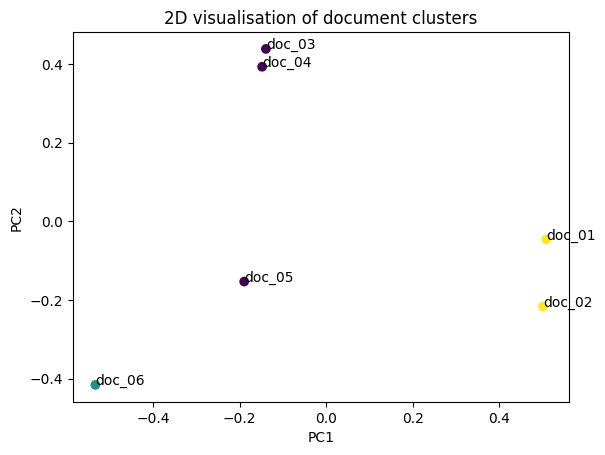

In [ ]:
from sklearn.decomposition import PCA

# reduce teh high dimensional tf-idf vector into two dimensions
pca = PCA(n_components=2)
coords = pca.fit_transform(tfidf_matrix.toarray())

plt.figure()
#define x and y axis data, and colour each cluster differently
plt.scatter(coords[:, 0], coords[:, 1], c=doc_text["cluster"])

#add teh doc_id label
for i, doc_id in enumerate(doc_text["doc_id"]):
    plt.text(coords[i, 0], coords[i, 1], doc_id)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D visualisation of document clusters")
plt.show()

### **Step 8 Summary of EDA**

The analysis has enabled

*   PDF document files to be imported
*   text to be extracted
*   metadata to be stored per document
*   classifying documents by type
*   basic descriptive statistics per document and document type
*   enhanced cleaning of text enabling analysis
*   analysis of words and vocabulary per document
*   clustering analysis to determine patterns of similarity

Topic modelling has not been performed as part of EDA on the basis that the corpus was only 6 documents and clustering analysis already assisted in determining thematic differences between documents based on vocabulary.

Lemmatisation was not performed as part of this EDA. It could have been useful to enable conceptual grouping of terms (risk, risks, risky, ...). Whilst this may have reduced the vocabulary size, this could have impaired the actual meaning of this formal, regulatory text, hence was deemed inappropriate.

The EDA did not include sentence counts per document or paragraph length distributions, which could assist in future application design to assist in selecting a chunking approach.

The EDA can be performed on any document corpus, and the insights should help to inform subsequent application modelling approach.


### **References**

This assignment of EDA of unstructured data involved a significant learning curve with the application of techniques that had not previously been performed by this student. <br><br>
The following books were used to understand the basics of the various techniques and how to apply them as part of EDA using Python. In addition to the code examples in the books, browser-based search was necessary to understand correct python syntax and usage.
1.   Jones A, Kruger, C, Johnston B. "The Unsupervised Learning Workshop. 2020. Packt Publishing.
2.   Alammar J., Grootendorst M. "Hands-on Large Language Models: Language Understanding and Generation". 2024. O'Reilly.
3.   Oluleye A. "Exploratory Data Analysis with Python: Cookbook". 2023. Packt Publishing.
4.   Isson J.P. "Unstructured Data Analytics". 2018. Wiley.
5.   Verdhan V. "Data Without Labels". 2025. Manning.
6.   Theobald O. "Machine Learning for Absolute Beginners". 2021 Third Edition. Scatterplotpress.
7.   Seefeld K. "Unstructured Data: A Primer for Beginning Analyst in the Age of AI". 2025. Data Analytics Curriculum.






 .

 .

 .

 .